# Sparkle Movie — Exploration & Analyse des données

**Contexte :** Nous travaillons pour une plateforme de streaming vidéo qui souhaite améliorer l'expérience utilisateur en proposant des recommandations personnalisées. Nous utilisons le dataset **MovieLens** pour analyser les comportements des utilisateurs et préparer un système de recommandation.

**Problématique :** Comment recommander des films pertinents à un utilisateur en se basant sur ses préférences passées et celles d'utilisateurs similaires ?

---

## 1. Préparation de l'environnement

### 1.1 Installation des dépendances

Les librairies nécessaires pour ce projet :

In [6]:
# Installation des librairies (à exécuter une seule fois)
# !pip install pyspark matplotlib seaborn pandas

### 1.2 Configuration de la session Spark

In [7]:
import os

# Configuration Java (nécessaire sur Windows)
os.environ["JAVA_HOME"] = "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot"

from pyspark.sql import SparkSession

# Création de la session Spark
spark = SparkSession.builder \
    .appName("SparkleMovie") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# Réduction du niveau de log pour plus de lisibilité
spark.sparkContext.setLogLevel("WARN")

print(f"Session Spark créée avec succès !")
print(f"Version Spark : {spark.version}")
print(f"Application ID : {spark.sparkContext.applicationId}")

Session Spark créée avec succès !
Version Spark : 4.1.1
Application ID : local-1776337222365


### 1.3 Extraction du dataset MovieLens

Le fichier zip est déjà téléchargé localement. On l'extrait si besoin.

In [8]:
import os
import zipfile

ZIP_PATH = "../ml-32m.zip"   # zip déjà téléchargé dans le dossier parent
DATA_DIR = "../ml-32m"

if not os.path.exists(DATA_DIR):
    print("Extraction du dataset MovieLens 32M...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(".")
    print("Extraction terminée.")
else:
    print("Dataset déjà extrait.")

print("Fichiers disponibles :")
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024 * 1024)
    print(f"  {f:<20} {size_mb:>8.1f} Mo")

Dataset déjà extrait.
Fichiers disponibles :
  README.txt                0.0 Mo
  checksums.txt             0.0 Mo
  links.csv                 1.9 Mo
  movies.csv                4.0 Mo
  ratings.csv             836.4 Mo
  tags.csv                 69.0 Mo


### 1.4 Vérification de l'environnement

On s'assure que toutes les librairies sont disponibles et que l'environnement est prêt.

In [9]:
import pyspark
import pandas as pd
import matplotlib
import seaborn

print("Versions des librairies :")
print(f"  PySpark   : {pyspark.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  Matplotlib: {matplotlib.__version__}")
print(f"  Seaborn   : {seaborn.__version__}")
print()
print("Environnement prêt !")

Versions des librairies :
  PySpark   : 4.1.1
  Pandas    : 3.0.1
  Matplotlib: 3.10.8
  Seaborn   : 0.13.2

Environnement prêt !


## 2. Chargement et exploration des données

### 2.1 Importation de csv dans des DataFrames Spark

In [10]:
df_ratings = spark.read.csv("../ml-32m/ratings.csv", header=True, inferSchema=True)
df_movies = spark.read.csv("../ml-32m/movies.csv", header=True, inferSchema=True)
# header=True : utilise la première ligne pour les noms de colonnes
# inferSchema=True : détecte automatiquement si une colonne est un nombre ou du texte

In [11]:
print("Aperçu des notes :")
df_ratings.show(10)

Aperçu des notes :
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|     17|   4.0|944249077|
|     1|     25|   1.0|944250228|
|     1|     29|   2.0|943230976|
|     1|     30|   5.0|944249077|
|     1|     32|   5.0|943228858|
|     1|     34|   2.0|943228491|
|     1|     36|   1.0|944249008|
|     1|     80|   5.0|944248943|
|     1|    110|   3.0|943231119|
|     1|    111|   5.0|944249008|
+------+-------+------+---------+
only showing top 10 rows


In [12]:
print("Aperçu des films :")
df_movies.show(10)

Aperçu des films :
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
+-------+--------------------+--------------------+
only showing top 10 rows


### 2.2 Nettoyage des données

In [13]:
print(f"Total ratings: {df_ratings.count()}")
print(f"Total movies: {df_movies.count()}")

Total ratings: 32000204
Total movies: 87585


In [14]:
df_ratings_final = df_ratings.na.drop(subset=["userId", "movieId", "rating"]) \
                             .dropDuplicates(["userId", "movieId"]) \
                             .filter("rating >= 0 AND rating <= 5")
#supprime les lignes vides, les doublons et les notes inferieures à 0 et supérieur à 5

In [15]:
df_movies_final = df_movies.na.drop(subset=["movieId", "title"]) \
                           .dropDuplicates(["movieId"])
#supprime les lignes vides et les doublons

In [16]:
print(f"Lignes après nettoyage : {df_ratings_final.count()}")
print(f"Lignes après nettoyage : {df_movies_final.count()}")

Lignes après nettoyage : 32000204
Lignes après nettoyage : 87585


### 2.3 Analyse des données

In [17]:
df_combined = df_ratings_final.join(df_movies_final, on="movieId", how="inner")
# jointure des dataset

In [18]:
from pyspark.sql import functions as F

In [19]:
top_rated_movies = df_combined.groupBy("title") \
    .agg(
        F.avg("rating").alias("moyenne_note"),
        F.count("rating").alias("nombre_de_votes")
    ) \
    .filter("nombre_de_votes > 100") \
    .orderBy(F.desc("moyenne_note"))

top_rated_movies.show(10, truncate=False)
# Groupement par titre, calcul de la moyenne et du nombre de votes

+--------------------------------+------------------+---------------+
|title                           |moyenne_note      |nombre_de_votes|
+--------------------------------+------------------+---------------+
|Planet Earth II (2016)          |4.4468302658486705|1956           |
|Planet Earth (2006)             |4.444369063772049 |2948           |
|Band of Brothers (2001)         |4.426538598363572 |2811           |
|Shawshank Redemption, The (1994)|4.404613860039444 |102929         |
|Cosmos                          |4.330081300813008 |615            |
|Godfather, The (1972)           |4.317030403371463 |66440          |
|Parasite (2019)                 |4.312253641816624 |11670          |
|Blue Planet II (2017)           |4.300085984522786 |1163           |
|Twin Peaks (1989)               |4.298684210526316 |1140           |
|Twelve Angry Men (1954)         |4.28619153674833  |449            |
+--------------------------------+------------------+---------------+
only showing top 10 

In [20]:
df_genres = df_combined.withColumn("genre_individuel", F.explode(F.split(F.col("genres"), "\\|")))
# Separation de la chaine de caracteres en liste, puis "exploser" la liste en plusieurs lignes

In [21]:
genre_popularity = df_genres.groupBy("genre_individuel") \
    .agg(
        F.count("rating").alias("nombre_de_notes"),
        F.avg("rating").alias("note_moyenne")
    ) \
    .orderBy(F.desc("nombre_de_notes"))

genre_popularity.show()
# Calculer la popularité (nombre de notes par genre)

+------------------+---------------+------------------+
|  genre_individuel|nombre_de_notes|      note_moyenne|
+------------------+---------------+------------------+
|             Drama|       13973271|3.6824540581800784|
|            Comedy|       11206925|3.4323858239436777|
|            Action|        9665213| 3.476407141777424|
|          Thriller|        8679464|3.5317020152396505|
|         Adventure|        7590522|3.5234385724723545|
|            Sci-Fi|        5717337|3.4916991949223912|
|           Romance|        5524615|3.5450028644529983|
|             Crime|        5373051|3.6917711184948736|
|           Fantasy|        3702759| 3.512174705402107|
|          Children|        2731841|3.4392409733948646|
|           Mystery|        2615322| 3.673102967818112|
|            Horror|        2492315|3.3071549944529486|
|         Animation|        2214562|3.6153322869262636|
|               War|        1594110|3.7916994435766664|
|              IMAX|        1494179| 3.593312447

### 2.4 Stats descriptives

On analyse trois dimensions cles avant de construire les modeles :
la **distribution des notes**, l'**activite des utilisateurs** et la **popularite des films**.
Ces stats permettent de comprendre la forme des donnees et d'anticiper les limites des algorithmes.

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

#### Distribution des notes

Comment les utilisateurs repartissent-ils leurs notes entre 0.5 et 5 ?

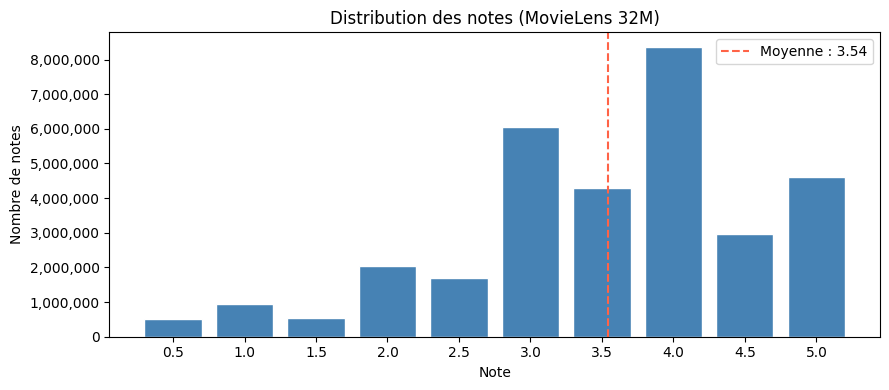

Note moyenne globale : 3.54 / 5
=> Biais de selection : les utilisateurs notent surtout les films qu ils ont choisi de regarder.


In [23]:
rating_dist = df_ratings_final.groupBy('rating').count().orderBy('rating').toPandas()
note_moyenne = (rating_dist['rating'] * rating_dist['count']).sum() / rating_dist['count'].sum()

plt.figure(figsize=(9, 4))
plt.bar(rating_dist['rating'], rating_dist['count'], width=0.4, color='steelblue', edgecolor='white')
plt.axvline(note_moyenne, color='tomato', linestyle='--', linewidth=1.5, label=f'Moyenne : {note_moyenne:.2f}')
plt.title('Distribution des notes (MovieLens 32M)')
plt.xlabel('Note')
plt.ylabel('Nombre de notes')
plt.xticks([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend()
plt.tight_layout()
plt.show()

print(f'Note moyenne globale : {note_moyenne:.2f} / 5')
print('=> Biais de selection : les utilisateurs notent surtout les films qu ils ont choisi de regarder.')

#### Activite des utilisateurs

Combien de films chaque utilisateur a-t-il note ?
Cette distribution conditionne directement la qualite des predictions ALS.

> **Pourquoi afficher la mediane ET la moyenne ?**
> La **moyenne** est sensible aux valeurs extremes (ici, un utilisateur a note 33 332 films).
> La **mediane** coupe la population en deux moities egales et est robuste aux outliers.
> Un ecart important entre les deux signale une **distribution asymetrique** — c'est precisement le cas ici, ce qui justifie d'utiliser la mediane comme indicateur principal.

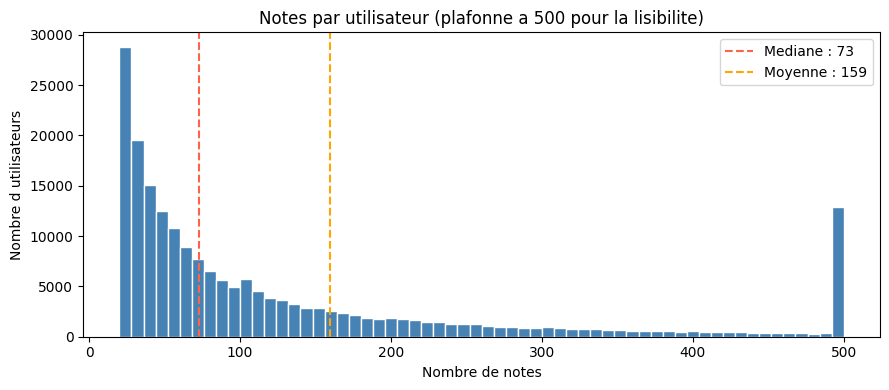

Notes par utilisateur :
  Mediane : 73  films notes
  Moyenne : 159.2 films notes  (ecart = distribution tres asymetrique)
  Max     : 33,332  (outlier : bot ou import en masse)
  Min     : 20   (seuil du dataset, deja filtre)


In [24]:
notes_par_user = df_ratings_final.groupBy('userId').count().toPandas()

mediane_u = notes_par_user['count'].median()
moyenne_u = notes_par_user['count'].mean()

plt.figure(figsize=(9, 4))
plt.hist(notes_par_user['count'].clip(upper=500), bins=60, color='steelblue', edgecolor='white')
plt.axvline(mediane_u, color='tomato', linestyle='--', linewidth=1.5, label=f'Mediane : {mediane_u:.0f}')
plt.axvline(moyenne_u, color='orange', linestyle='--', linewidth=1.5, label=f'Moyenne : {moyenne_u:.0f}')
plt.title('Notes par utilisateur (plafonne a 500 pour la lisibilite)')
plt.xlabel('Nombre de notes')
plt.ylabel('Nombre d utilisateurs')
plt.legend()
plt.tight_layout()
plt.show()

print('Notes par utilisateur :')
print(f'  Mediane : {mediane_u:.0f}  films notes')
print(f'  Moyenne : {moyenne_u:.1f} films notes  (ecart = distribution tres asymetrique)')
print(f'  Max     : {notes_par_user["count"].max():,}  (outlier : bot ou import en masse)')
print(f'  Min     : {notes_par_user["count"].min():,}   (seuil du dataset, deja filtre)')

#### Popularite des films

Combien de notes chaque film a-t-il recues ?
La **longue traine** est caracteristique : quelques blockbusters concentrent l'essentiel des votes,
pendant que des milliers de films restent quasi inconnus des algorithmes.

> **Pourquoi afficher la mediane ET la moyenne ?**
> Quelques blockbusters (ex. Shawshank : 102 929 votes) gonflent artificiellement la moyenne.
> La **mediane a 5 notes** est bien plus representative de la realite : la moitie des films du catalogue est au seuil du cold start.
> Sans la mediane, on sous-estimerait massivement le probleme.

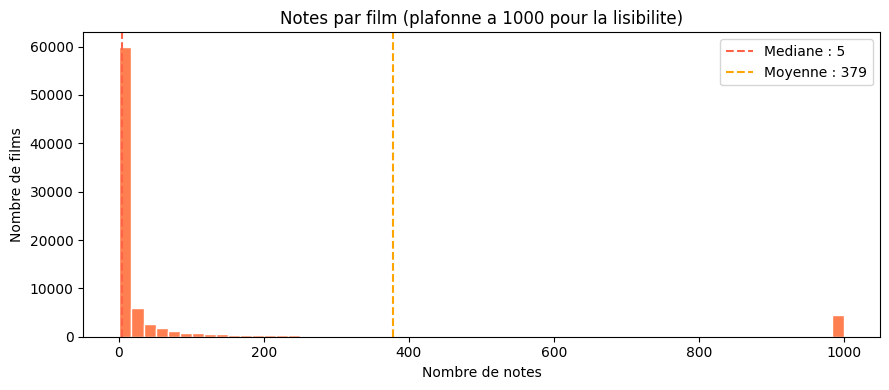

Notes par film :
  Mediane : 5   notes  (la moitie des films est au seuil du cold start)
  Moyenne : 379.0 notes  (quelques blockbusters tirent la moyenne)
  Max     : 102,929  (Shawshank Redemption : le plus note ET le mieux note)
  Films avec moins de 5 notes : 40,548 / 84,432 (48.0%)


In [25]:
notes_par_film = df_ratings_final.groupBy('movieId').count().toPandas()

mediane_f = notes_par_film['count'].median()
moyenne_f = notes_par_film['count'].mean()
films_lt5 = (notes_par_film['count'] < 5).sum()
pct_lt5   = films_lt5 / len(notes_par_film) * 100

plt.figure(figsize=(9, 4))
plt.hist(notes_par_film['count'].clip(upper=1000), bins=60, color='coral', edgecolor='white')
plt.axvline(mediane_f, color='tomato', linestyle='--', linewidth=1.5, label=f'Mediane : {mediane_f:.0f}')
plt.axvline(moyenne_f, color='orange', linestyle='--', linewidth=1.5, label=f'Moyenne : {moyenne_f:.0f}')
plt.title('Notes par film (plafonne a 1000 pour la lisibilite)')
plt.xlabel('Nombre de notes')
plt.ylabel('Nombre de films')
plt.legend()
plt.tight_layout()
plt.show()

print('Notes par film :')
print(f'  Mediane : {mediane_f:.0f}   notes  (la moitie des films est au seuil du cold start)')
print(f'  Moyenne : {moyenne_f:.1f} notes  (quelques blockbusters tirent la moyenne)')
print(f'  Max     : {notes_par_film["count"].max():,}  (Shawshank Redemption : le plus note ET le mieux note)')
print(f'  Films avec moins de 5 notes : {films_lt5:,} / {len(notes_par_film):,} ({pct_lt5:.1f}%)')

### 2.5 Cold Start Problem

Le **cold start** est le probleme central des systemes de recommandation :
- **Utilisateur froid** : pas assez d'historique -> ALS ne peut pas faire de prediction fiable
- **Film froid** : trop peu de notes recues -> invisible pour le collaborative filtering

On quantifie l'ampleur du probleme pour **justifier l'utilisation de 3 algorithmes complementaires**.

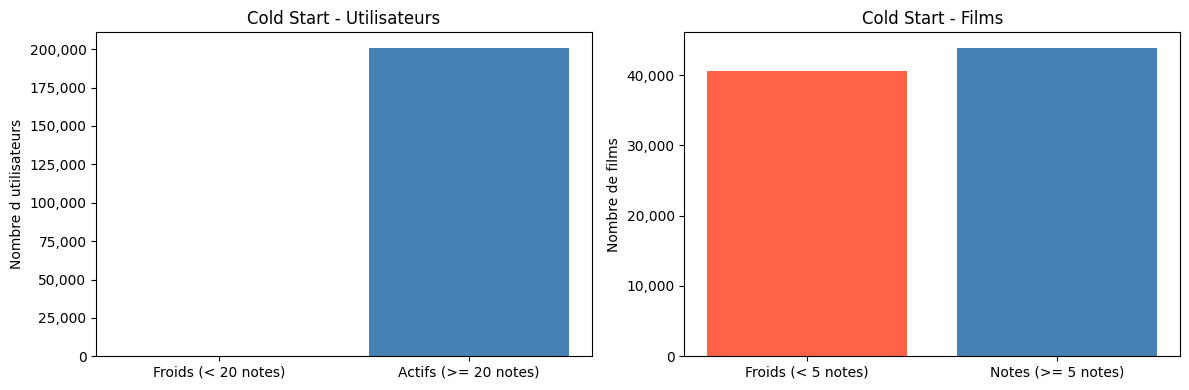

In [26]:
seuil_user = 20
seuil_film = 5

users_froids = (notes_par_user['count'] < seuil_user).sum()
films_froids = (notes_par_film['count'] < seuil_film).sum()
total_users  = len(notes_par_user)
total_films  = len(notes_par_film)
pct_u = users_froids / total_users * 100
pct_f = films_froids / total_films * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ['Froids (< 20 notes)', 'Actifs (>= 20 notes)'],
    [users_froids, total_users - users_froids],
    color=['tomato', 'steelblue']
)
axes[0].set_title('Cold Start - Utilisateurs')
axes[0].set_ylabel('Nombre d utilisateurs')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(
    ['Froids (< 5 notes)', 'Notes (>= 5 notes)'],
    [films_froids, total_films - films_froids],
    color=['tomato', 'steelblue']
)
axes[1].set_title('Cold Start - Films')
axes[1].set_ylabel('Nombre de films')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [27]:
print('=' * 55)
print('SYNTHESE COLD START')
print('=' * 55)
print(f'Utilisateurs froids (< {seuil_user} notes) : {users_froids:>6,} / {total_users:,} ({pct_u:.1f}%)')
print(f'Films froids        (<  {seuil_film} notes) : {films_froids:>6,} / {total_films:,} ({pct_f:.1f}%)')
print()
print('Implications pour les modeles :')
print('  ALS (Collaborative Filtering)')
print(f'    -> Fiable pour 100% des utilisateurs (dataset pre-filtre a {seuil_user} notes min)')
print(f'    -> Aveugle sur {pct_f:.0f}% des films (trop peu de notes pour collaborer)')
print('  Content-Based Filtering')
print('    -> Resout le cold start films (utilise les genres, independant des notes)')
print('  KNN')
print('    -> Complementaire pour les utilisateurs avec peu d historique en production reelle')

SYNTHESE COLD START
Utilisateurs froids (< 20 notes) :      0 / 200,948 (0.0%)
Films froids        (<  5 notes) : 40,548 / 84,432 (48.0%)

Implications pour les modeles :
  ALS (Collaborative Filtering)
    -> Fiable pour 100% des utilisateurs (dataset pre-filtre a 20 notes min)
    -> Aveugle sur 48% des films (trop peu de notes pour collaborer)
  Content-Based Filtering
    -> Resout le cold start films (utilise les genres, independant des notes)
  KNN
    -> Complementaire pour les utilisateurs avec peu d historique en production reelle


---
## Conclusion de l'exploration

### Reponse a la problematique

> **Comment recommander des films pertinents a un utilisateur, en s'appuyant sur ses preferences passees et sur le comportement d'utilisateurs similaires ?**

L'analyse exploratoire du dataset MovieLens 32M (32 000 204 notes, 87 585 films, 200 948 utilisateurs) permet de repondre a cette question en plusieurs points :

### Ce que les donnees nous apprennent

| Observation | Valeur | Implication |
|-------------|--------|-------------|
| Note moyenne globale | 3.54 / 5 | Les utilisateurs notent positivement — biais de selection a prendre en compte |
| Mediane notes/utilisateur | 73 films | La majorite des utilisateurs a suffisamment d'historique pour ALS |
| Films avec < 5 notes | 48% du catalogue | La moitie des films est invisible pour le Collaborative Filtering |
| Genre le plus populaire | Drama (14M notes) | A privilegier dans les profils de contenu |
| Genre le mieux note | Film-Noir (3.92) | Audience de niche tres engagee |

### Choix des algorithmes justifies par les donnees

- **ALS (Collaborative Filtering)** : adapte car 100% des utilisateurs ont au moins 20 notes. Il exploite les similarites de comportement entre utilisateurs pour predire les preferences.
- **Content-Based Filtering** : indispensable pour les 48% de films froids que ALS ne peut pas couvrir. Il recommande en se basant sur les genres des films aimes.
- **KNN** : complement naturel pour trouver les utilisateurs les plus proches et affiner les recommandations dans des cas ou ALS manque de recul.

La suite du projet (notebook `02_modelisation.ipynb`) met en oeuvre ces trois approches et les compare.